# Validación Geográfica LOBO (Leave-One-Block-Out)

**Hipótesis de validación externa (H3):** La caída de **F2** en la validación externa por bloques geográficos (LOBO) respecto a la CV 5-fold interna es **≤ 0.05**.

- **Variables:** VI = Bloque geográfico (UTM) · VD = Generalización geográfica
- **Métricas:** **ΔF2** (criterio de decisión — coherente con la métrica del proyecto), con **Recall**, **PR-AUC** y **Brier Score** como apoyo.

Esta validación externa permite determinar si el modelo generaliza a zonas no vistas durante el entrenamiento (independencia geográfica), o si sufre de *dataset shift* espacial.

## Imports y configuración

In [2]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import xgboost as xgb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import ks_2samp
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, average_precision_score,
                             brier_score_loss, f1_score, fbeta_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Rutas
BASE_DIR = '..' if os.path.exists('../data/processed/data_procesada.csv') else '.'
DATA_PATH = f"{BASE_DIR}/data/processed/data_procesada.csv"
OUTPUT_DIR = 'outputs_LOBO' if BASE_DIR == '..' else 'notebooks/outputs_LOBO'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Prefijos de artefactos de sprints previos reutilizados por el modelo campeon
_PREF = (lambda s: f'outputs_{s}' if BASE_DIR == '..' else f'notebooks/outputs_{s}')
_PREFIX_S2, _PREFIX_S3, _PREFIX_S4 = _PREF('sprint2'), _PREF('sprint3'), _PREF('sprint4')

# Umbral de decision FINAL del proyecto (politica global anidada del sprint 4)
THRESHOLD_FINAL = json.load(open(f'{_PREFIX_S4}/resumen_sprint4.json'))['calibracion_umbral']['umbral_global_nested']

print('=== Validacion Geografica LOBO (modelo campeon del sprint 4) ===')
print(f'Datos : {DATA_PATH}')
print(f'Output: {OUTPUT_DIR}')
print(f'Umbral de decision final (metrica F2, global nested): {THRESHOLD_FINAL:.4f}')

=== Validacion Geografica LOBO (modelo campeon del sprint 4) ===
Datos : ../data/processed/data_procesada.csv
Output: outputs_LOBO
Umbral de decision final (metrica F2, global nested): 0.1842


## Cargar datos y reconstruir modelo final

In [3]:
# -- Features del MODELO CAMPEON (sprint 4): 27 geoquimicas crudas + cluster_litho_prob --
# cluster_litho_prob se reproduce con el clustering litologico CLR+GMM ya ajustado en el
# sprint 2 (transformacion NO supervisada, determinista por muestra; no depende del split).
_clust = joblib.load(f'{_PREFIX_S2}/models/clustering_litho.pkl')
GMM_LITHO, SCALER_CLR = _clust['gmm'], _clust['scaler_clr']
MIN_POS_CLR, COLS_INMOV = _clust['min_pos_clr'], _clust['cols_inmov']

def clr_transform(X_df, cols, min_pos):
    """CLR de Aitchison (sprint 2): log(x / media_geometrica). Ceros -> min_pos/2."""
    Xc = X_df[cols].copy()
    for c in cols:
        Xc[c] = Xc[c].replace(0, min_pos[c] / 2).clip(lower=min_pos[c] / 2)
    log_x = np.log(Xc)
    return log_x.subtract(log_x.mean(axis=1), axis=0)

def agregar_cluster_litho_prob(df_in):
    """Reproduce la feature cluster_litho_prob del campeon con el GMM del sprint 2."""
    clr = clr_transform(df_in, COLS_INMOV, MIN_POS_CLR)
    Z = SCALER_CLR.transform(clr)
    return GMM_LITHO.predict_proba(Z).max(axis=1)

# Lista exacta de las 28 features del campeon (seleccion SHAP del sprint 3)
FEATURES = json.load(open(f'{_PREFIX_S3}/data/features_s3_por_modelo.json'))['XGBoost']

df = pd.read_csv(DATA_PATH)
df_fe = df.copy()
df_fe['cluster_litho_prob'] = agregar_cluster_litho_prob(df_fe)

assert all(f in df_fe.columns for f in FEATURES), 'Faltan features del campeon en el dataset'

print(f'Dataset : {df_fe.shape[0]} muestras, {df.shape[1]} columnas originales')
print(f'Features del modelo campeon: {len(FEATURES)} '
      f'(27 geoquimicas crudas + cluster_litho_prob)')
print(f'Target  : {df_fe.target_Au.value_counts().to_dict()} '
      f'({100*df_fe.target_Au.mean():.1f}% positivos)')

Dataset : 2132 muestras, 51 columnas originales
Features del modelo campeon: 28 (27 geoquimicas crudas + cluster_litho_prob)
Target  : {0: 1872, 1: 260} (12.2% positivos)


## Definición de bloques geográficos

Mediana East = 6552.9 | Mediana North = 6988.2
          n  n_pos  pct_pos
bloque                     
NE      555     52     9.37
NO      511     74    14.48
SO      555    108    19.46
SE      511     26     5.09


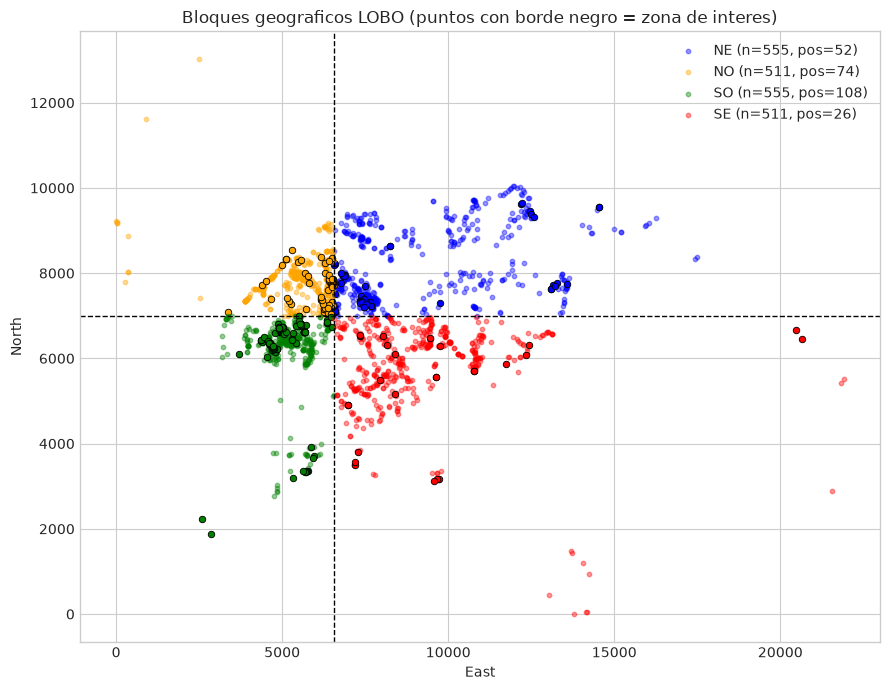

In [4]:
east_med = df_fe['East'].median()
north_med = df_fe['North'].median()

def asignar_bloque(row):
    if row['East'] >= east_med and row['North'] >= north_med: return 'NE'
    elif row['East'] < east_med and row['North'] >= north_med: return 'NO'
    elif row['East'] < east_med and row['North'] < north_med: return 'SO'
    else: return 'SE'

df_fe['bloque'] = df_fe.apply(asignar_bloque, axis=1)
BLOQUES = ['NE', 'NO', 'SO', 'SE']

resumen_bloques = (df_fe.groupby('bloque')
                   .agg(n=('target_Au', 'size'), n_pos=('target_Au', 'sum'))
                   .reindex(BLOQUES))
resumen_bloques['pct_pos'] = (100 * resumen_bloques['n_pos'] / resumen_bloques['n']).round(2)
resumen_bloques.to_csv(f'{OUTPUT_DIR}/lobo_resumen_bloques.csv')
print(f'Mediana East = {east_med:.1f} | Mediana North = {north_med:.1f}')
print(resumen_bloques)

# Mapa de bloques
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'NE': 'blue', 'NO': 'orange', 'SO': 'green', 'SE': 'red'}
for b in BLOQUES:
    sub = df_fe[df_fe['bloque'] == b]
    ax.scatter(sub['East'], sub['North'], s=10, alpha=0.4, c=colors[b],
               label=f"{b} (n={len(sub)}, pos={int(sub.target_Au.sum())})")
    pos = sub[sub['target_Au'] == 1]
    ax.scatter(pos['East'], pos['North'], s=22, c=colors[b], edgecolors='k', linewidths=0.6)
ax.axvline(east_med, color='k', ls='--', lw=1)
ax.axhline(north_med, color='k', ls='--', lw=1)
ax.set_xlabel('East'); ax.set_ylabel('North')
ax.set_title('Bloques geograficos LOBO (puntos con borde negro = zona de interes)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_mapa_bloques.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

## Entrenamiento y funciones de evaluación

In [5]:
# Hiperparametros del MODELO CAMPEON final (sprint 4): XGBoost optimizado con Optuna (seed=42)
XGB_PARAMS = {
    'n_estimators': 52, 'max_depth': 9, 'learning_rate': 0.11069143219393454,
    'subsample': 0.8645035840204937, 'colsample_bytree': 0.8856351733429728,
    'min_child_weight': 2, 'reg_alpha': 0.7404465173409036, 'reg_lambda': 3.5846572854427263,
    'random_state': SEED, 'eval_metric': 'logloss', 'tree_method': 'hist',
}

def construir_pipeline_base():
    """Pipeline base identico al del campeon: StandardScaler -> SMOTE -> XGBoost."""
    return ImbPipeline([
        ('sc', StandardScaler()),
        ('sam', SMOTE(random_state=SEED)),
        ('clf', xgb.XGBClassifier(**XGB_PARAMS)),
    ])

def entrenar_modelo(X_tr, y_tr):
    """Modelo CAMPEON del sprint 4: pipeline base envuelto en calibracion isotonica
    (CalibratedClassifierCV, cv=5). Ajuste SOLO con datos de train."""
    model = CalibratedClassifierCV(construir_pipeline_base(), method='isotonic', cv=5)
    model.fit(X_tr, y_tr)
    return model

def ajustar_base_para_shap(X_tr, y_tr):
    """Ajusta el pipeline base (sin calibrar) para interpretabilidad SHAP.
    La calibracion isotonica es monotona y no altera el ranking de atribuciones."""
    return construir_pipeline_base().fit(X_tr, y_tr)

def evaluar_bloque(y_true, y_prob, y_pred, n_boot=1000, conf=0.95):
    """Metricas + IC 95% bootstrap (metrica de decision del proyecto: F2)."""
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob); y_pred = np.asarray(y_pred)
    n, n_pos = len(y_true), int(y_true.sum())
    out = {'n': n, 'n_pos': n_pos,
           'Accuracy': accuracy_score(y_true, y_pred),
           'Precision': precision_score(y_true, y_pred, zero_division=0),
           'Recall': recall_score(y_true, y_pred, zero_division=0),
           'F2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
           'F1': f1_score(y_true, y_pred, zero_division=0),
           'PR_AUC': average_precision_score(y_true, y_prob),
           'ROC_AUC': roc_auc_score(y_true, y_prob),
           'Brier': brier_score_loss(y_true, y_prob)}
    rng = np.random.RandomState(SEED)
    bf2, bpr, broc = [], [], []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        bf2.append(fbeta_score(y_true[idx], y_pred[idx], beta=2, zero_division=0))
        bpr.append(average_precision_score(y_true[idx], y_prob[idx]))
        broc.append(roc_auc_score(y_true[idx], y_prob[idx]))
    a = (1 - conf) / 2
    ci = lambda arr: (np.percentile(arr, 100 * a), np.percentile(arr, 100 * (1 - a))) if arr else (np.nan, np.nan)
    out['F2_CI_low'], out['F2_CI_high'] = ci(bf2)
    out['PR_AUC_CI_low'], out['PR_AUC_CI_high'] = ci(bpr)
    out['ROC_AUC_CI_low'], out['ROC_AUC_CI_high'] = ci(broc)
    return out

def psi_feature(expected, actual, bins=10):
    """Population Stability Index entre distribucion train (expected) y bloque held-out (actual)."""
    expected = np.asarray(expected, dtype=float); actual = np.asarray(actual, dtype=float)
    qs = np.unique(np.nanquantile(expected, np.linspace(0, 1, bins + 1)))
    if len(qs) < 3:
        return 0.0
    qs[0], qs[-1] = -np.inf, np.inf
    e_pct = np.histogram(expected, bins=qs)[0] / max(len(expected), 1)
    a_pct = np.histogram(actual, bins=qs)[0] / max(len(actual), 1)
    e_pct = np.clip(e_pct, 1e-4, None); a_pct = np.clip(a_pct, 1e-4, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

print('Modelo campeon listo: StandardScaler -> SMOTE -> XGBoost + calibracion isotonica |',
      len(FEATURES), 'features | umbral F2 =', round(THRESHOLD_FINAL, 4))

Modelo campeon listo: StandardScaler -> SMOTE -> XGBoost + calibracion isotonica | 28 features | umbral F2 = 0.1842


## Loop LOBO: entrenar con N-1 bloques

In [6]:
metricas_lobo, psi_rows, ks_rows, shap_rows = [], [], [], []
predicciones = []

for b in BLOQUES:
    train_mask = df_fe['bloque'] != b
    test_mask = df_fe['bloque'] == b
    X_tr, y_tr = df_fe.loc[train_mask, FEATURES], df_fe.loc[train_mask, 'target_Au']
    X_te, y_te = df_fe.loc[test_mask, FEATURES], df_fe.loc[test_mask, 'target_Au']

    # Modelo campeon (pipeline calibrado); recibe X crudo y escala internamente
    model = entrenar_modelo(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= THRESHOLD_FINAL).astype(int)

    m = evaluar_bloque(y_te, y_prob, y_pred)
    m['Bloque'] = b
    m['n_train'] = int(train_mask.sum())
    metricas_lobo.append(m)

    pred_df = df_fe.loc[test_mask, ['East', 'North', 'Level', 'Au_ppm', 'target_Au', 'bloque']].copy()
    pred_df['y_prob'], pred_df['y_pred'] = y_prob, y_pred
    predicciones.append(pred_df)

    # --- Monitoreo de shift: PSI y KS por feature (train N-1 bloques vs bloque held-out) ---
    for f in FEATURES:
        psi_rows.append({'Bloque': b, 'Feature': f,
                         'PSI': psi_feature(X_tr[f], X_te[f])})
        ks_stat, ks_p = ks_2samp(X_tr[f], X_te[f])
        ks_rows.append({'Bloque': b, 'Feature': f, 'KS_stat': ks_stat, 'p_value': ks_p})

    # --- SHAP top-10 sobre el bloque held-out (XGBoost base del pipeline) ---
    base = ajustar_base_para_shap(X_tr, y_tr)
    X_te_scaled = base.named_steps['sc'].transform(X_te)
    explainer = shap.TreeExplainer(base.named_steps['clf'])
    shap_vals = explainer.shap_values(X_te_scaled)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    orden = np.argsort(mean_abs)[::-1]
    for rank, idx in enumerate(orden[:10], start=1):
        shap_rows.append({'Bloque': b, 'Rank': rank, 'Feature': FEATURES[idx],
                          'mean_abs_SHAP': float(mean_abs[idx])})

    print(f"Bloque {b}: train={m['n_train']} test={m['n']} (pos={m['n_pos']}) | "
          f"F2={m['F2']:.4f} [{m['F2_CI_low']:.3f}-{m['F2_CI_high']:.3f}] | "
          f"PR-AUC={m['PR_AUC']:.4f} | Brier={m['Brier']:.4f}")

df_lobo = pd.DataFrame(metricas_lobo)[
    ['Bloque', 'n_train', 'n', 'n_pos', 'Accuracy', 'Precision', 'Recall', 'F2',
     'F2_CI_low', 'F2_CI_high', 'PR_AUC', 'PR_AUC_CI_low', 'PR_AUC_CI_high',
     'ROC_AUC', 'ROC_AUC_CI_low', 'ROC_AUC_CI_high', 'Brier']]
df_lobo.to_csv(f'{OUTPUT_DIR}/lobo_metricas_por_bloque.csv', index=False)

df_pred = pd.concat(predicciones, ignore_index=True)
df_pred.to_csv(f'{OUTPUT_DIR}/lobo_predicciones.csv', index=False)

df_psi = pd.DataFrame(psi_rows)
df_ks = pd.DataFrame(ks_rows)
df_shap = pd.DataFrame(shap_rows)
df_psi.to_csv(f'{OUTPUT_DIR}/lobo_psi_por_bloque.csv', index=False)
df_ks.to_csv(f'{OUTPUT_DIR}/lobo_ks_por_bloque.csv', index=False)
df_shap.to_csv(f'{OUTPUT_DIR}/lobo_shap_top10_por_bloque.csv', index=False)

print('\nResumen LOBO:')
print(f"  F2 medio     = {df_lobo['F2'].mean():.4f} +/- {df_lobo['F2'].std():.4f}")
print(f"  PR-AUC medio = {df_lobo['PR_AUC'].mean():.4f} +/- {df_lobo['PR_AUC'].std():.4f}")
print(f"  Brier medio  = {df_lobo['Brier'].mean():.4f} +/- {df_lobo['Brier'].std():.4f}")

Bloque NE: train=1577 test=555 (pos=52) | F2=0.6392 [0.537-0.714] | PR-AUC=0.5111 | Brier=0.0621
Bloque NO: train=1621 test=511 (pos=74) | F2=0.4522 [0.354-0.553] | PR-AUC=0.4405 | Brier=0.1067
Bloque SO: train=1577 test=555 (pos=108) | F2=0.6038 [0.519-0.687] | PR-AUC=0.7384 | Brier=0.1136
Bloque SE: train=1621 test=511 (pos=26) | F2=0.4955 [0.361-0.605] | PR-AUC=0.3445 | Brier=0.0555

Resumen LOBO:
  F2 medio     = 0.5477 +/- 0.0882
  PR-AUC medio = 0.5086 +/- 0.1677
  Brier medio  = 0.0845 +/- 0.0299


## Validación interna de referencia (CV 5-fold estratificada)

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_all, y_all = df_fe[FEATURES], df_fe['target_Au']

cv_rows = []
for i, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), start=1):
    X_tr, y_tr = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
    X_te, y_te = X_all.iloc[te_idx], y_all.iloc[te_idx]
    model = entrenar_modelo(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= THRESHOLD_FINAL).astype(int)
    cv_rows.append({'Fold': i,
                    'F2': fbeta_score(y_te, y_pred, beta=2, zero_division=0),
                    'F1': f1_score(y_te, y_pred, zero_division=0),
                    'PR_AUC': average_precision_score(y_te, y_prob),
                    'ROC_AUC': roc_auc_score(y_te, y_prob),
                    'Brier': brier_score_loss(y_te, y_prob)})
    print(f"Fold {i}: F2={cv_rows[-1]['F2']:.4f} PR-AUC={cv_rows[-1]['PR_AUC']:.4f} "
          f"Brier={cv_rows[-1]['Brier']:.4f}")

df_cv = pd.DataFrame(cv_rows)
df_cv.to_csv(f'{OUTPUT_DIR}/lobo_cv5fold_referencia.csv', index=False)
F2_CV, PR_CV, BRIER_CV = df_cv['F2'].mean(), df_cv['PR_AUC'].mean(), df_cv['Brier'].mean()
print(f'\nCV 5-fold: F2={F2_CV:.4f} +/- {df_cv.F2.std():.4f} | '
      f'PR-AUC={PR_CV:.4f} +/- {df_cv.PR_AUC.std():.4f} | Brier={BRIER_CV:.4f}')

Fold 1: F2=0.7973 PR-AUC=0.7223 Brier=0.0548
Fold 2: F2=0.7338 PR-AUC=0.6686 Brier=0.0645
Fold 3: F2=0.7143 PR-AUC=0.7006 Brier=0.0576
Fold 4: F2=0.6655 PR-AUC=0.6390 Brier=0.0687
Fold 5: F2=0.7000 PR-AUC=0.6643 Brier=0.0657

CV 5-fold: F2=0.7222 +/- 0.0489 | PR-AUC=0.6790 +/- 0.0327 | Brier=0.0623


## Comparación LOBO vs CV 5-fold

Bloque   n  n_pos     F2  F2_CI_low  F2_CI_high  PR_AUC  Brier  F2_CV_ref  Delta_F2  PR_AUC_CV_ref  Delta_PR_AUC  Delta_Brier  Cumple_H3
    NE 555     52 0.6392     0.5370      0.7143  0.5111 0.0621     0.7222    0.0830          0.679        0.1678      -0.0002      False
    NO 511     74 0.4522     0.3542      0.5533  0.4405 0.1067     0.7222    0.2700          0.679        0.2384       0.0444      False
    SO 555    108 0.6038     0.5185      0.6870  0.7384 0.1136     0.7222    0.1184          0.679       -0.0595       0.0513      False
    SE 511     26 0.4955     0.3608      0.6049  0.3445 0.0555     0.7222    0.2267          0.679        0.3345      -0.0067      False

F2 CV 5-fold (interna) = 0.7222
F2 LOBO medio (externa-geografica) = 0.5477 ± 0.0882
Delta F2 medio = 0.1745 -> criterio H3 (<= 0.05): NO CUMPLE
Bloques que cumplen individualmente: 0/4


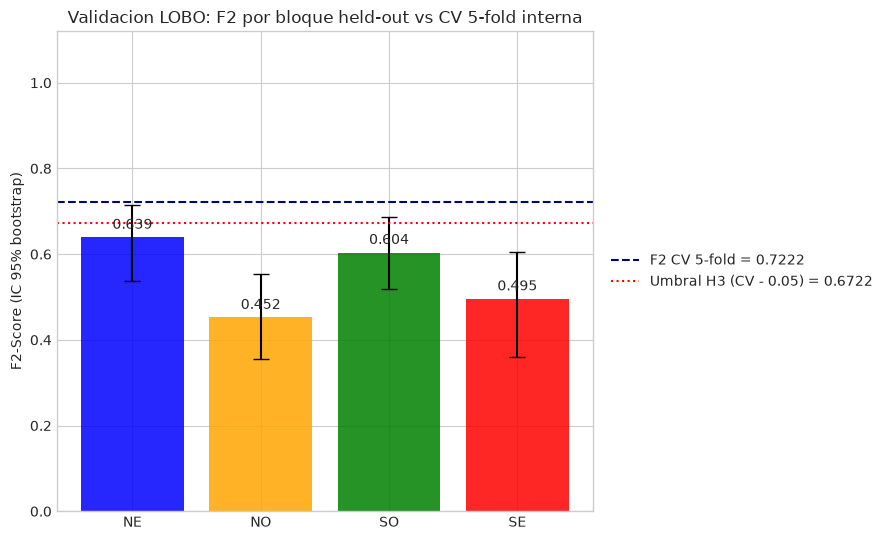

In [8]:
comp = df_lobo[['Bloque', 'n', 'n_pos', 'F2', 'F2_CI_low', 'F2_CI_high',
                'PR_AUC', 'Brier']].copy()
comp['F2_CV_ref'] = F2_CV
comp['Delta_F2'] = F2_CV - comp['F2']
comp['PR_AUC_CV_ref'] = PR_CV
comp['Delta_PR_AUC'] = PR_CV - comp['PR_AUC']
comp['Delta_Brier'] = comp['Brier'] - BRIER_CV
comp['Cumple_H3'] = comp['Delta_F2'] <= 0.05
comp.to_csv(f'{OUTPUT_DIR}/lobo_vs_cv_comparacion.csv', index=False)
print(comp.round(4).to_string(index=False))

delta_medio = F2_CV - df_lobo['F2'].mean()
print(f"\nF2 CV 5-fold (interna) = {F2_CV:.4f}")
print(f"F2 LOBO medio (externa-geografica) = {df_lobo['F2'].mean():.4f} ± {df_lobo['F2'].std():.4f}")
print(f"Delta F2 medio = {delta_medio:.4f} -> criterio H3 (<= 0.05): "
      f"{'CUMPLE' if delta_medio <= 0.05 else 'NO CUMPLE'}")
print(f"Bloques que cumplen individualmente: {int(comp['Cumple_H3'].sum())}/4")

# Grafico de barras F2 con IC 95%
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(comp))
err = np.array([comp['F2'] - comp['F2_CI_low'], comp['F2_CI_high'] - comp['F2']])
bars = ax.bar(x, comp['F2'], yerr=err, capsize=6,
              color=[colors[b] for b in comp['Bloque']], alpha=0.85)
ax.axhline(F2_CV, color='navy', ls='--', lw=1.5, label=f'F2 CV 5-fold = {F2_CV:.4f}')
ax.axhline(F2_CV - 0.05, color='red', ls=':', lw=1.5,
           label=f'Umbral H3 (CV - 0.05) = {F2_CV - 0.05:.4f}')
for xi, f2v in zip(x, comp['F2']):
    ax.text(xi, min(f2v + 0.02, 1.06), f'{f2v:.3f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(comp['Bloque'])
ax.set_ylim(0, 1.12); ax.set_ylabel('F2-Score (IC 95% bootstrap)')
ax.set_title('Validacion LOBO: F2 por bloque held-out vs CV 5-fold interna')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_f2_por_bloque.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

## Monitoreo de dataset shift entre bloques

=== PSI y KS por bloque ===
Bloque  PSI_max Feature_PSI_max  n_features_PSI>0.20  Alerta_PSI  n_features_KS_p<0.05  Alerta_KS
    NE   0.2577          Zr_ppm                    1        True                    23       True
    NO   0.7340          Sr_ppm                   19        True                    26       True
    SO   0.7841          Te_ppm                    8        True                    26       True
    SE   0.4342          Mn_ppm                    4        True                    26       True


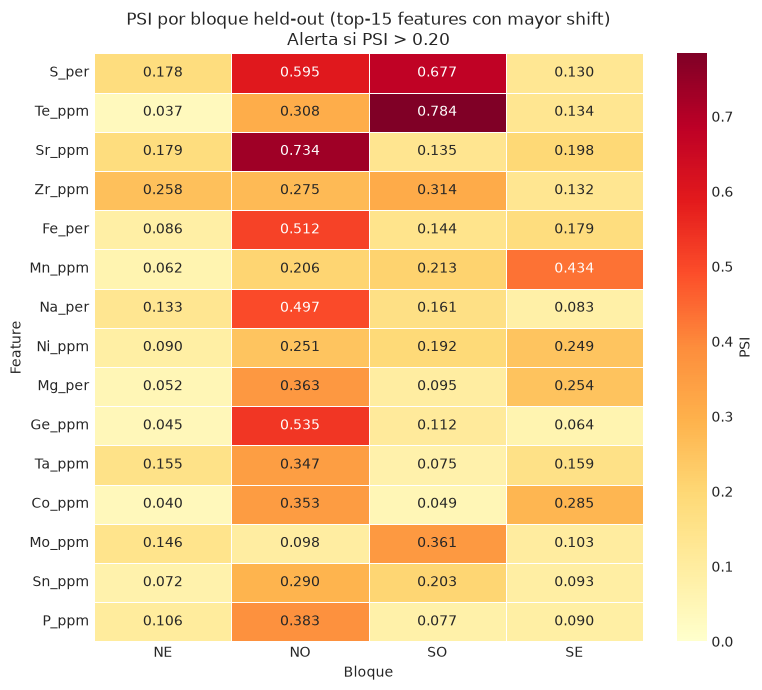


Top-10 features con KS significativo mas frecuente:
Feature
Be_ppm    4
Ge_ppm    4
Cs_ppm    4
Ce_ppm    4
Mg_per    4
Fe_per    4
Rb_ppm    4
S_per     4
P_ppm     4
Na_per    4
dtype: int64


In [9]:
alertas = []
for b in BLOQUES:
    psi_b = df_psi[df_psi['Bloque'] == b]
    ks_b = df_ks[df_ks['Bloque'] == b]
    n_psi_alerta = int((psi_b['PSI'] > 0.20).sum())
    n_ks_signif = int((ks_b['p_value'] < 0.05).sum())
    alertas.append({'Bloque': b,
                    'PSI_max': psi_b['PSI'].max(),
                    'Feature_PSI_max': psi_b.loc[psi_b['PSI'].idxmax(), 'Feature'],
                    'n_features_PSI>0.20': n_psi_alerta,
                    'Alerta_PSI': n_psi_alerta > 0,
                    'n_features_KS_p<0.05': n_ks_signif,
                    'Alerta_KS': n_ks_signif >= 5})

df_alertas = pd.DataFrame(alertas)
print('=== PSI y KS por bloque ===')
print(df_alertas.round(4).to_string(index=False))

# Heatmap PSI: top-15 features con mayor PSI medio
top_feats = (df_psi.groupby('Feature')['PSI'].mean()
             .sort_values(ascending=False).head(15).index)
pivot = df_psi[df_psi['Feature'].isin(top_feats)].pivot(
    index='Feature', columns='Bloque', values='PSI').reindex(top_feats)[BLOQUES]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=max(0.4, pivot.values.max()),
            cbar_kws={'label': 'PSI'}, linewidths=0.5, ax=ax)
ax.set_title('PSI por bloque held-out (top-15 features con mayor shift)\nAlerta si PSI > 0.20')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_psi_heatmap.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

print('\nTop-10 features con KS significativo mas frecuente:')
print(df_ks[df_ks['p_value'] < 0.05].groupby('Feature').size()
      .sort_values(ascending=False).head(10))

## Comparación del ranking SHAP top-10 entre bloques

=== Top-10 SHAP por bloque held-out ===
Bloque      NE      NO                  SO      SE
Rank                                              
1       Sb_ppm  Sb_ppm              Sb_ppm  Sb_ppm
2       Te_ppm  Se_ppm              Se_ppm  Se_ppm
3       Ce_ppm  Te_ppm  cluster_litho_prob  Te_ppm
4       Se_ppm  Cd_ppm               U_ppm  Mo_ppm
5       As_ppm  Rb_ppm              As_ppm  Ce_ppm
6       Mo_ppm  Sn_ppm              Te_ppm  Na_per
7        U_ppm  Co_ppm              Zr_ppm  Cd_ppm
8       Sn_ppm  Mn_ppm              Ge_ppm  La_ppm
9       Be_ppm  As_ppm              Sn_ppm  Ge_ppm
10       S_per   S_per              Na_per  Mg_per

Ranking global (media entre bloques): ['Sb_ppm', 'Se_ppm', 'Te_ppm', 'cluster_litho_prob', 'Ce_ppm', 'U_ppm', 'Rb_ppm', 'As_ppm', 'Mo_ppm', 'Co_ppm']

Bloque  Top10_comunes_con_global  Alerta_SHAP
    NE                         7        False
    NO                         6         True
    SO                         6         True
    SE      

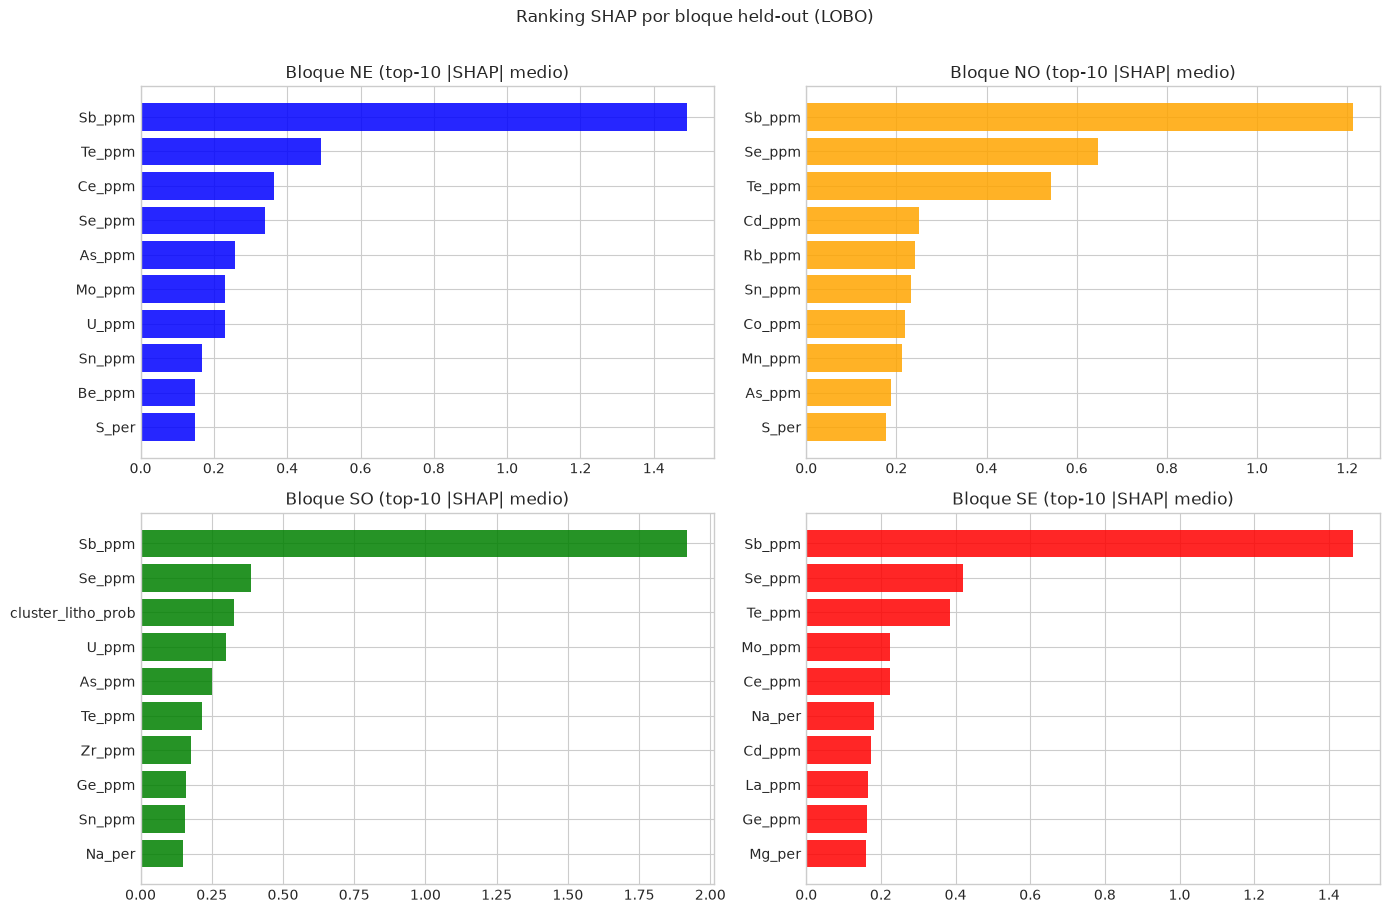

In [10]:
tabla_shap = df_shap.pivot(index='Rank', columns='Bloque', values='Feature')[BLOQUES]
print('=== Top-10 SHAP por bloque held-out ===')
print(tabla_shap.to_string())

# Ranking global de referencia: frecuencia + importancia media entre bloques
ranking_global = (df_shap.groupby('Feature')['mean_abs_SHAP'].mean()
                  .sort_values(ascending=False).head(10).index.tolist())
print('\nRanking global (media entre bloques):', ranking_global)

overlap_rows = []
for b in BLOQUES:
    top_b = df_shap[df_shap['Bloque'] == b].sort_values('Rank')['Feature'].tolist()
    inter = len(set(top_b) & set(ranking_global))
    overlap_rows.append({'Bloque': b, 'Top10_comunes_con_global': inter,
                         'Alerta_SHAP': inter < 7})
df_overlap = pd.DataFrame(overlap_rows)
print('\n' + df_overlap.to_string(index=False))

# Consolidado de alertas y regla de reentrenamiento (>= 2 alertas)
df_alertas = df_alertas.merge(df_overlap, on='Bloque')
df_alertas['n_alertas'] = (df_alertas[['Alerta_PSI', 'Alerta_KS', 'Alerta_SHAP']].sum(axis=1))
df_alertas['Requiere_reentrenar'] = df_alertas['n_alertas'] >= 2
df_alertas.to_csv(f'{OUTPUT_DIR}/lobo_alertas_shift.csv', index=False)
print('\n=== Consolidado de alertas de shift ===')
print(df_alertas[['Bloque', 'Alerta_PSI', 'Alerta_KS', 'Alerta_SHAP',
                  'n_alertas', 'Requiere_reentrenar']].to_string(index=False))

# Grafico comparativo de importancias SHAP
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
for ax, b in zip(axes.ravel(), BLOQUES):
    sub = df_shap[df_shap['Bloque'] == b].sort_values('mean_abs_SHAP')
    ax.barh(sub['Feature'], sub['mean_abs_SHAP'], color=colors[b], alpha=0.85)
    ax.set_title(f'Bloque {b} (top-10 |SHAP| medio)')
plt.suptitle('Ranking SHAP por bloque held-out (LOBO)', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lobo_shap_por_bloque.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()

## Resumen

In [11]:
peor = df_lobo.loc[df_lobo['F2'].idxmin()]
mejor = df_lobo.loc[df_lobo['F2'].idxmax()]
delta_medio = F2_CV - df_lobo['F2'].mean()
cumple_h3 = delta_medio <= 0.05
n_bloques_ok = int((F2_CV - df_lobo['F2'] <= 0.05).sum())

resumen = f"""
================================================================
RESUMEN EJECUTIVO - VALIDACION GEOGRAFICA LOBO
================================================================
Dataset: {len(df_fe)} muestras | {len(FEATURES)} features | K=4 bloques (grilla por medianas East/North)
Modelo por fold: StandardScaler -> SMOTE (solo train) -> XGBoost + calibracion isotonica (CalibratedClassifierCV cv=5); 28 features del campeon (sprint 4, seed=42)
Umbral de decision (metrica F2, politica global anidada del sprint 4): {THRESHOLD_FINAL:.4f}

1) VALIDACION INTERNA (CV 5-fold estratificada, mismo pipeline):
   F2 = {F2_CV:.4f} ± {df_cv['F2'].std():.4f} | PR-AUC = {PR_CV:.4f} | Brier = {BRIER_CV:.4f}

2) VALIDACION EXTERNA-GEOGRAFICA (LOBO):
   F2 medio = {df_lobo['F2'].mean():.4f} ± {df_lobo['F2'].std():.4f}
   PR-AUC medio = {df_lobo['PR_AUC'].mean():.4f} ± {df_lobo['PR_AUC'].std():.4f}
   Brier medio = {df_lobo['Brier'].mean():.4f} ± {df_lobo['Brier'].std():.4f}
   Mejor bloque : {mejor['Bloque']} (F2 = {mejor['F2']:.4f})
   Peor bloque  : {peor['Bloque']} (F2 = {peor['F2']:.4f}, IC95 [{peor['F2_CI_low']:.3f}, {peor['F2_CI_high']:.3f}])

3) CONTRASTE H3 (caida F2 <= 0.05 vs CV 5-fold):
   Delta F2 medio = {delta_medio:.4f} -> {'CUMPLE' if cumple_h3 else 'NO CUMPLE'}
   Bloques que cumplen individualmente: {n_bloques_ok}/4

4) MONITOREO DE SHIFT:
{df_alertas[['Bloque', 'PSI_max', 'n_features_PSI>0.20', 'n_features_KS_p<0.05',
             'Top10_comunes_con_global', 'n_alertas', 'Requiere_reentrenar']].round(3).to_string(index=False)}

5) LIMITACION (trabajo futuro):
   El LOBO opera dentro del dataset disponible (Ancash). La transferibilidad a
   yacimientos de otras regiones requiere datasets adicionales.
================================================================
"""
print(resumen)
with open(f'{OUTPUT_DIR}/lobo_resumen_ejecutivo.txt', 'w') as f:
    f.write(resumen)
print('Archivos generados en', OUTPUT_DIR, ':')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print('  -', f)


RESUMEN EJECUTIVO - VALIDACION GEOGRAFICA LOBO
Dataset: 2132 muestras | 28 features | K=4 bloques (grilla por medianas East/North)
Modelo por fold: StandardScaler -> SMOTE (solo train) -> XGBoost + calibracion isotonica (CalibratedClassifierCV cv=5); 28 features del campeon (sprint 4, seed=42)
Umbral de decision (metrica F2, politica global anidada del sprint 4): 0.1842

1) VALIDACION INTERNA (CV 5-fold estratificada, mismo pipeline):
   F2 = 0.7222 ± 0.0489 | PR-AUC = 0.6790 | Brier = 0.0623

2) VALIDACION EXTERNA-GEOGRAFICA (LOBO):
   F2 medio = 0.5477 ± 0.0882
   PR-AUC medio = 0.5086 ± 0.1677
   Brier medio = 0.0845 ± 0.0299
   Mejor bloque : NE (F2 = 0.6392)
   Peor bloque  : NO (F2 = 0.4522, IC95 [0.354, 0.553])

3) CONTRASTE H3 (caida F2 <= 0.05 vs CV 5-fold):
   Delta F2 medio = 0.1745 -> NO CUMPLE
   Bloques que cumplen individualmente: 0/4

4) MONITOREO DE SHIFT:
Bloque  PSI_max  n_features_PSI>0.20  n_features_KS_p<0.05  Top10_comunes_con_global  n_alertas  Requiere_reentre